# Google Ads Word Clouds

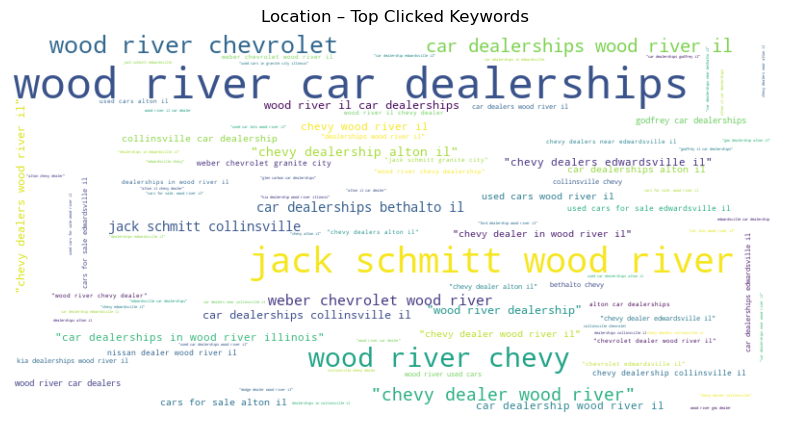

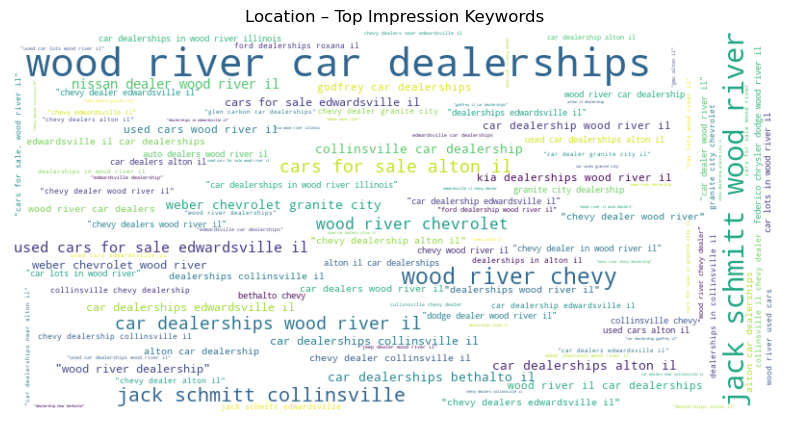

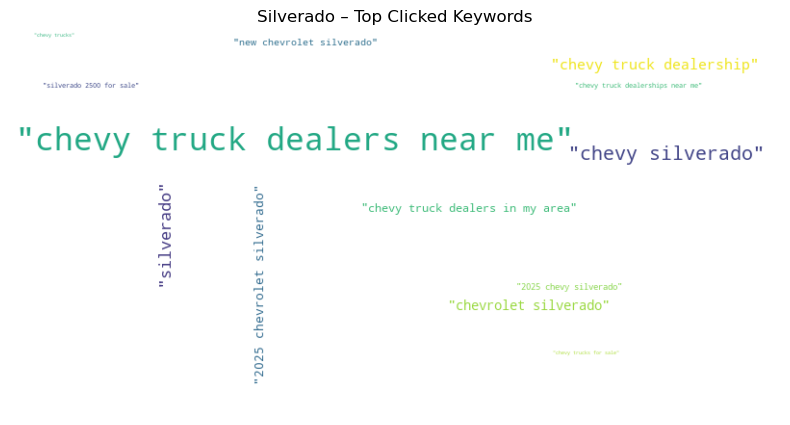

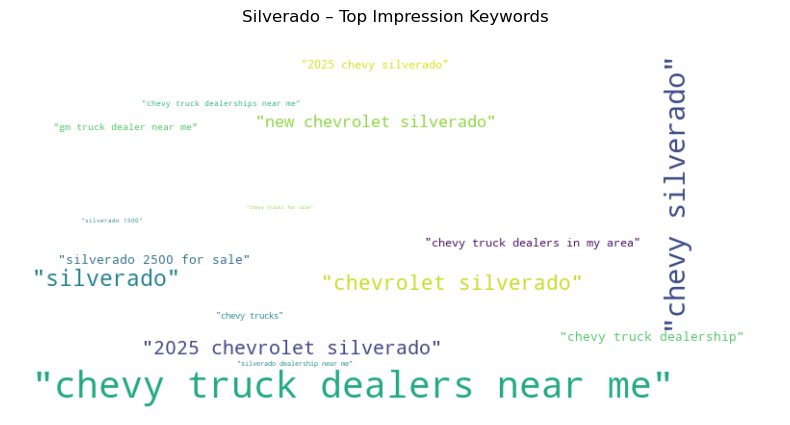

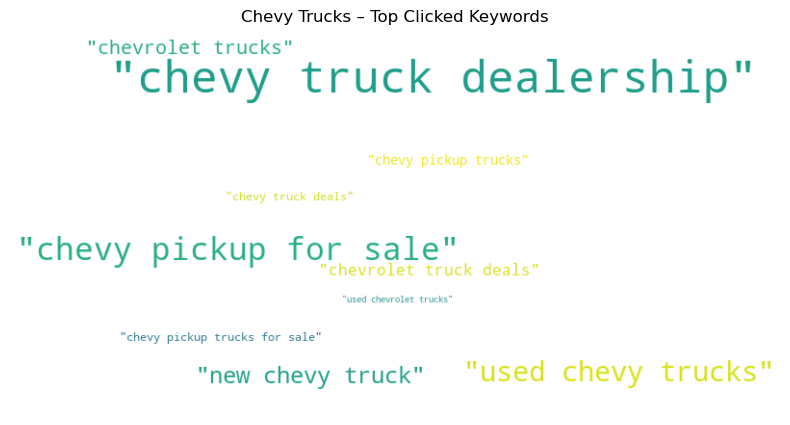

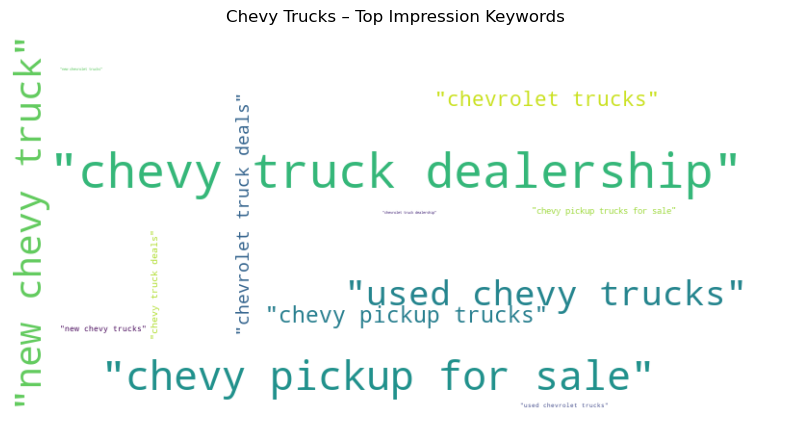

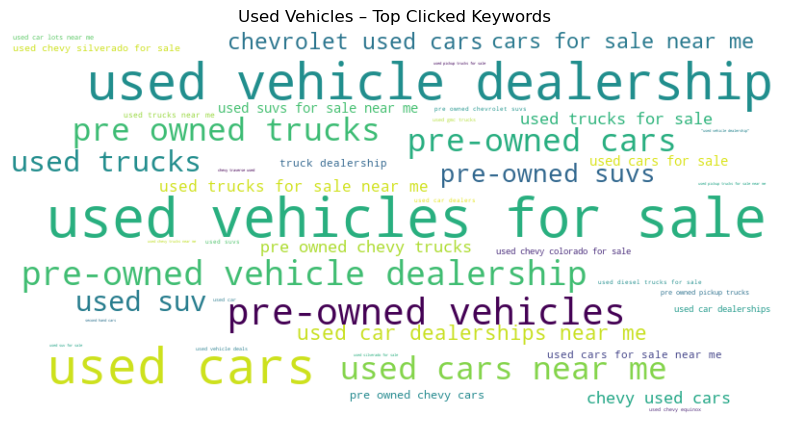

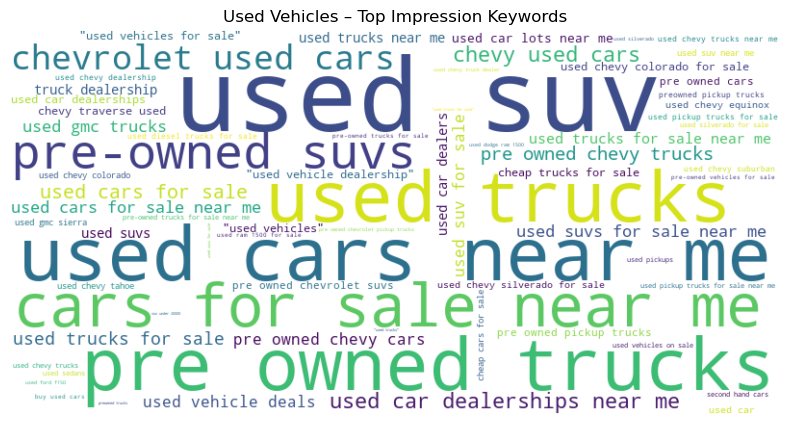

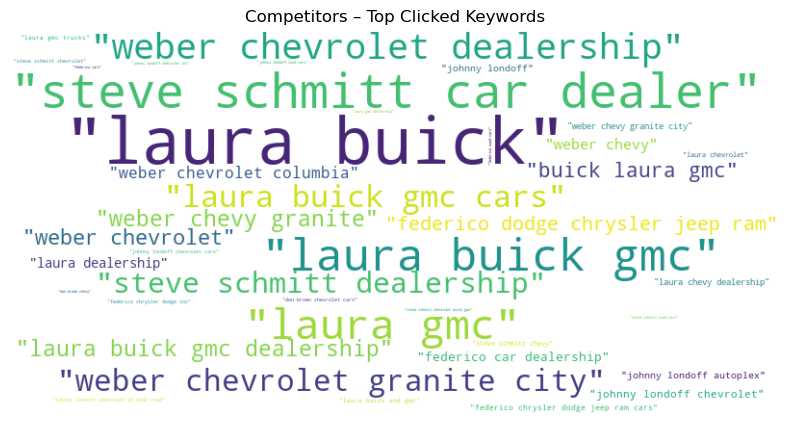

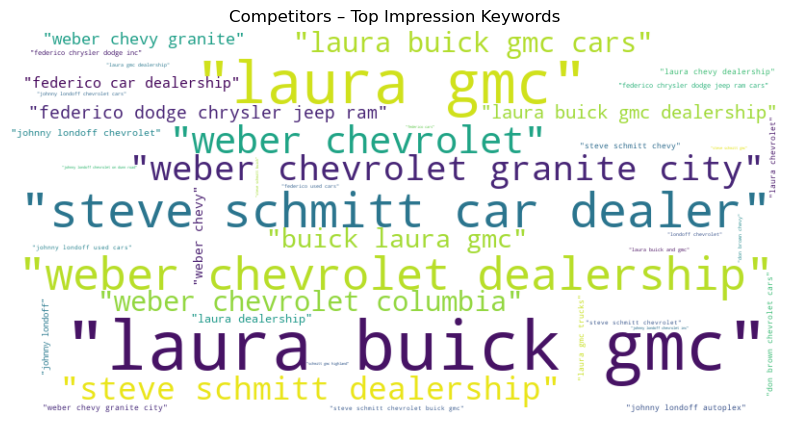

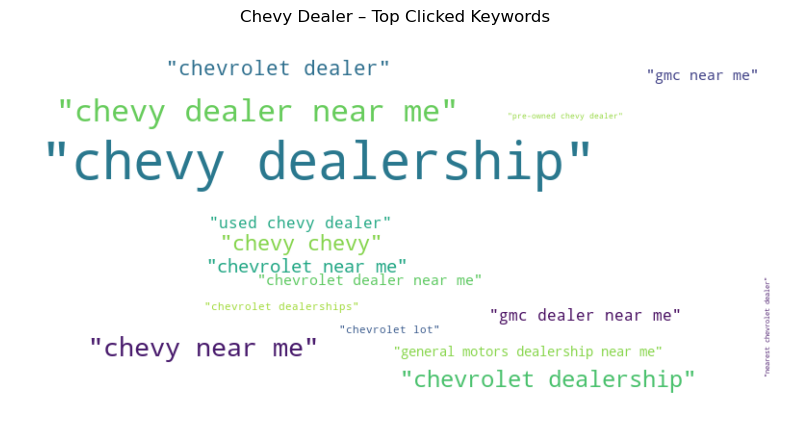

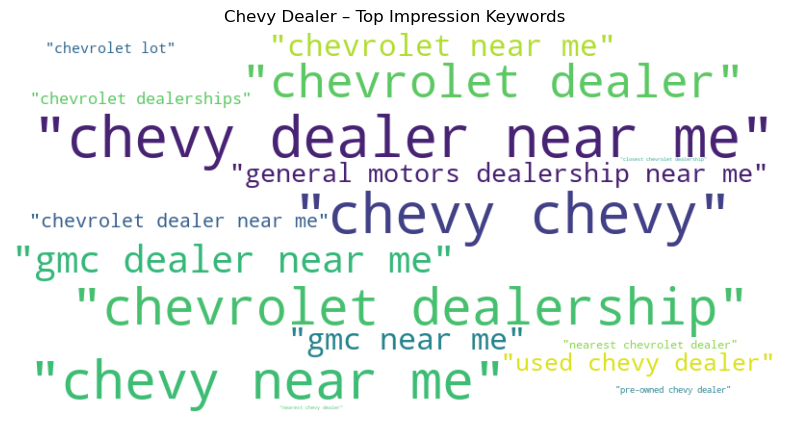

ZeroDivisionError: float division by zero

In [2]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

file_path = "/Users/robertwrobel/Downloads/skr.csv"
df = pd.read_csv(file_path)

df.columns = [col.strip().lower() for col in df.columns]

df['clicks'] = pd.to_numeric(df['clicks'], errors='coerce').fillna(0)
df['impressions'] = pd.to_numeric(df['impressions'], errors='coerce').fillna(0)

campaigns = df['campaign'].unique()

for campaign in campaigns:
    subset = df[df['campaign'] == campaign]

    #Build frequency dictionaries
    click_freq = dict(zip(subset['keyword'], subset['clicks']))
    impression_freq = dict(zip(subset['keyword'], subset['impressions']))

    #Word cloud for clicks
    wc_clicks = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(click_freq)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc_clicks, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"{campaign} – Top Clicked Keywords")
    plt.show()

    #Word cloud for impressions
    wc_impressions = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(impression_freq)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc_impressions, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"{campaign} – Top Impression Keywords")
    plt.show()



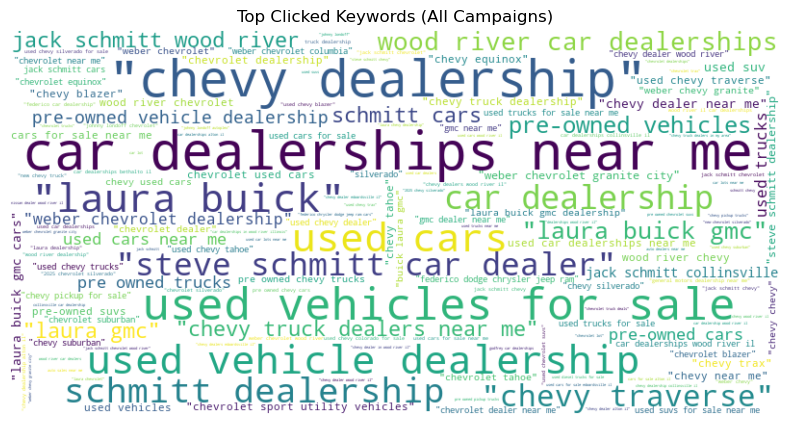

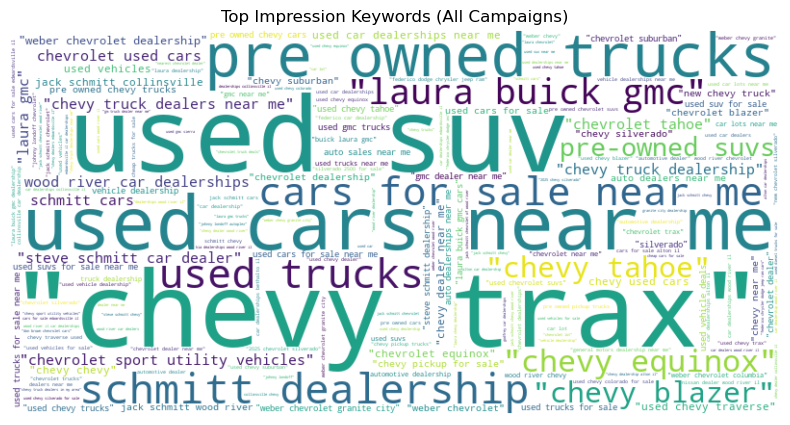

In [15]:
#Convert relevant columns to numeric
df['clicks'] = pd.to_numeric(df['clicks'], errors='coerce').fillna(0)
df['impressions'] = pd.to_numeric(df['impressions'], errors='coerce').fillna(0)

#Aggregate clicks and impressions by keyword
click_freq = df.groupby('keyword')['clicks'].sum().to_dict()
impression_freq = df.groupby('keyword')['impressions'].sum().to_dict()

#Word cloud for clicks
wc_clicks = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(click_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wc_clicks, interpolation='bilinear')
plt.axis('off')
plt.title("Top Clicked Keywords (All Campaigns)")
plt.show()

#Word cloud for impressions
wc_impressions = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(impression_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wc_impressions, interpolation='bilinear')
plt.axis('off')
plt.title("Top Impression Keywords (All Campaigns)")
plt.show()